In [3]:
# Install kagglehub
!pip install kagglehub

import kagglehub

# Download latest version of Chest X-ray dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


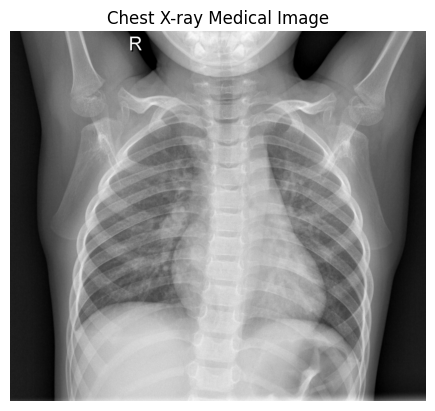

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Example: load one X-ray image
img_path = os.path.join(path, "chest_xray", "train", "NORMAL", "IM-0115-0001.jpeg")

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title("Chest X-ray Medical Image")
plt.axis("off")
plt.show()

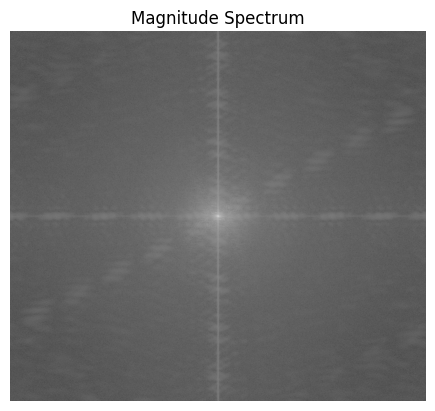

In [5]:
# Fourier Transform
dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

# Magnitude Spectrum
magnitude = 20 * np.log(np.abs(dft_shift) + 1)

plt.imshow(magnitude, cmap='gray')
plt.title("Magnitude Spectrum")
plt.axis("off")
plt.show()

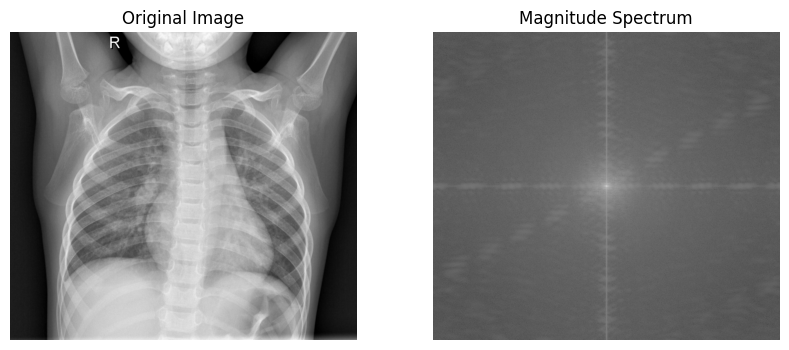

In [6]:
dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

magnitude = 20 * np.log(np.abs(dft_shift) + 1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(magnitude, cmap='gray')
plt.title("Magnitude Spectrum")
plt.axis("off")

plt.show()

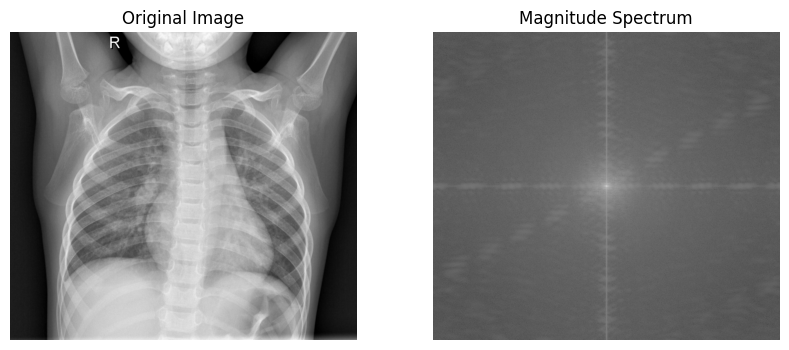

In [7]:
dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

magnitude = 20 * np.log(np.abs(dft_shift) + 1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(magnitude, cmap='gray')
plt.title("Magnitude Spectrum")
plt.axis("off")

plt.show()

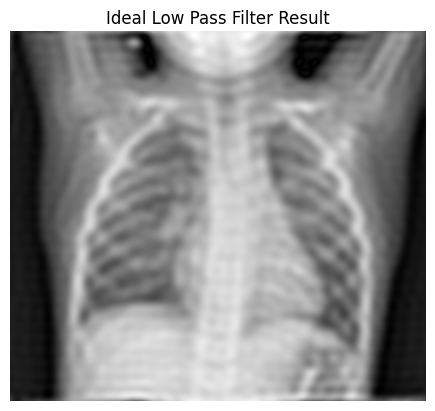

In [8]:
rows, cols = img.shape
crow, ccol = rows//2, cols//2

cutoff = 30
mask = np.zeros((rows, cols), np.uint8)

for i in range(rows):
    for j in range(cols):
        if (i-crow)**2 + (j-ccol)**2 <= cutoff**2:
            mask[i,j] = 1

filtered = dft_shift * mask

ishift = np.fft.ifftshift(filtered)
img_ilpf = np.abs(np.fft.ifft2(ishift))

plt.imshow(img_ilpf, cmap='gray')
plt.title("Ideal Low Pass Filter Result")
plt.axis("off")
plt.show()

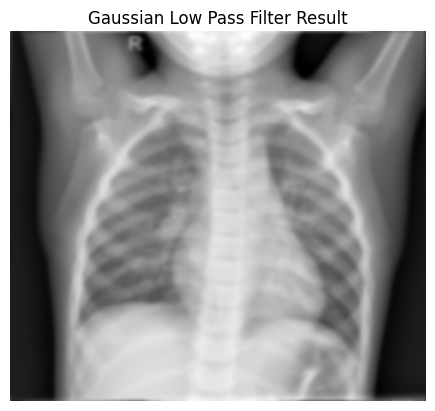

In [9]:
sigma = 30
mask = np.zeros((rows, cols), np.float32)

for i in range(rows):
    for j in range(cols):
        dist = (i-crow)**2 + (j-ccol)**2
        mask[i,j] = np.exp(-dist/(2*sigma*sigma))

filtered = dft_shift * mask
ishift = np.fft.ifftshift(filtered)
img_glpf = np.abs(np.fft.ifft2(ishift))

plt.imshow(img_glpf, cmap='gray')
plt.title("Gaussian Low Pass Filter Result")
plt.axis("off")
plt.show()

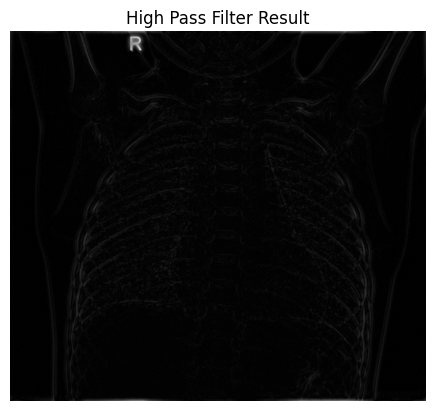

In [10]:
hp_mask = 1 - mask

filtered = dft_shift * hp_mask
ishift = np.fft.ifftshift(filtered)
img_hpf = np.abs(np.fft.ifft2(ishift))

plt.imshow(img_hpf, cmap='gray')
plt.title("High Pass Filter Result")
plt.axis("off")
plt.show()

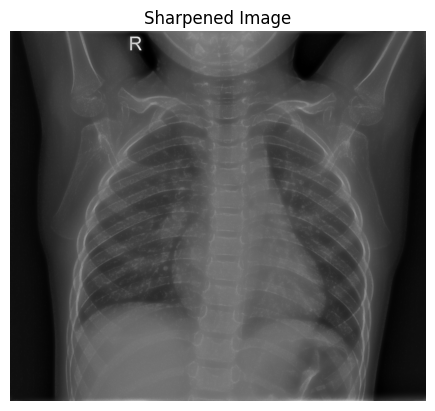

In [11]:
sharpened = img + img_hpf

plt.imshow(sharpened, cmap='gray')
plt.title("Sharpened Image")
plt.axis("off")
plt.show()

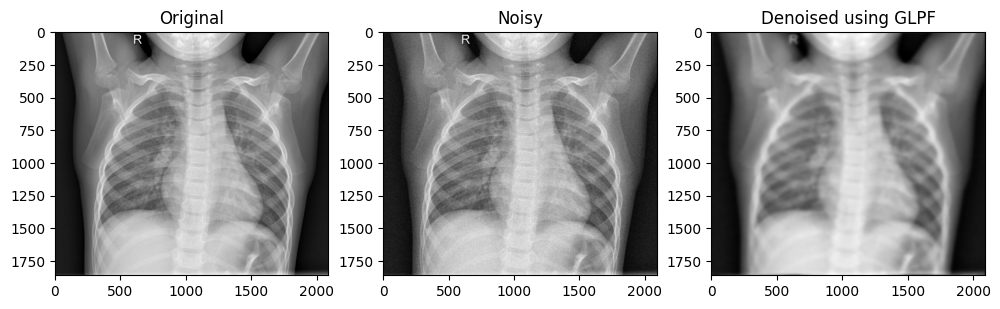

In [12]:
noise = np.random.normal(0, 25, img.shape)
noisy = img + noise
noisy = np.clip(noisy, 0, 255)

dft_noisy = np.fft.fftshift(np.fft.fft2(noisy))

filtered = dft_noisy * mask
ishift = np.fft.ifftshift(filtered)
denoised = np.abs(np.fft.ifft2(ishift))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy")

plt.subplot(1,3,3)
plt.imshow(denoised, cmap='gray')
plt.title("Denoised using GLPF")

plt.show()

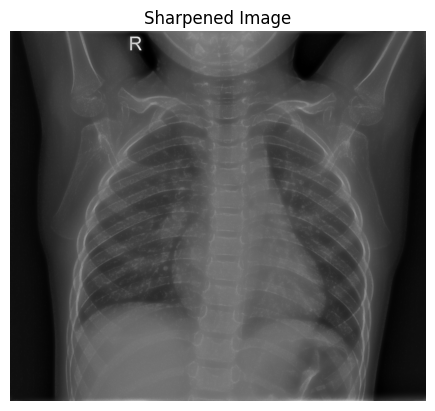

In [13]:
sharpened = img + img_hpf

plt.imshow(sharpened, cmap='gray')
plt.title("Sharpened Image")
plt.axis("off")
plt.show()

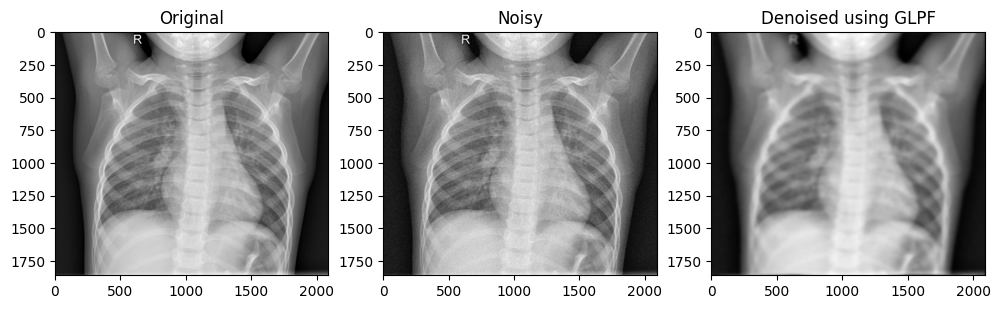

In [14]:
noise = np.random.normal(0, 25, img.shape)
noisy = img + noise
noisy = np.clip(noisy, 0, 255)

dft_noisy = np.fft.fftshift(np.fft.fft2(noisy))

filtered = dft_noisy * mask
ishift = np.fft.ifftshift(filtered)
denoised = np.abs(np.fft.ifft2(ishift))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy")

plt.subplot(1,3,3)
plt.imshow(denoised, cmap='gray')
plt.title("Denoised using GLPF")

plt.show()

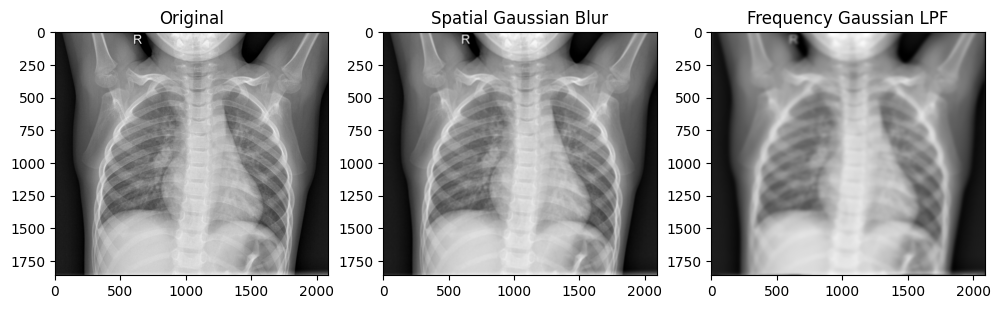

In [15]:
spatial = cv2.GaussianBlur(img, (11,11), 5)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(spatial, cmap='gray')
plt.title("Spatial Gaussian Blur")

plt.subplot(1,3,3)
plt.imshow(img_glpf, cmap='gray')
plt.title("Frequency Gaussian LPF")

plt.show()

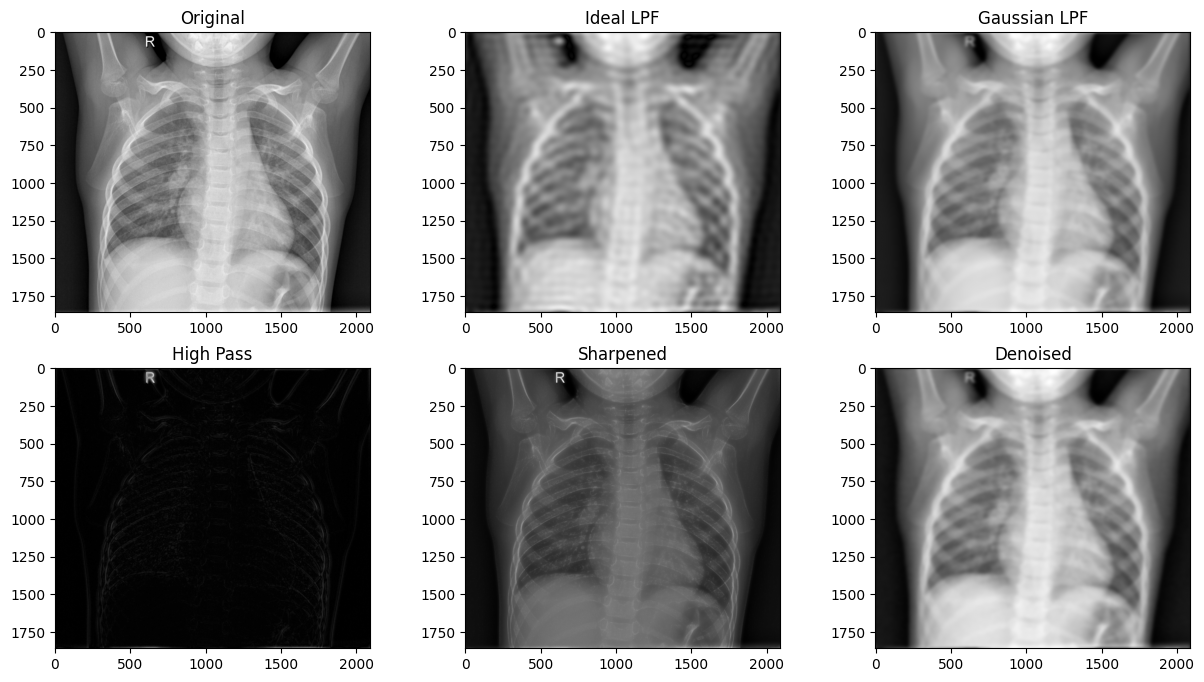

In [16]:
plt.figure(figsize=(15,8))

plt.subplot(2,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(2,3,2)
plt.imshow(img_ilpf, cmap='gray')
plt.title("Ideal LPF")

plt.subplot(2,3,3)
plt.imshow(img_glpf, cmap='gray')
plt.title("Gaussian LPF")

plt.subplot(2,3,4)
plt.imshow(img_hpf, cmap='gray')
plt.title("High Pass")

plt.subplot(2,3,5)
plt.imshow(sharpened, cmap='gray')
plt.title("Sharpened")

plt.subplot(2,3,6)
plt.imshow(denoised, cmap='gray')
plt.title("Denoised")

plt.show()